# Thin Source Separation: Full vs Nominal Resolution

This notebook tests **how much separation** two thin Faraday components need to be **each detectable**, and how **full vs nominal resolution** helps.

- **Full resolution** (λ²₀ = 0): narrower restoring beam → better separation of close components.
- **Nominal resolution** (λ²₀ = weighted mean): standard resolution, phase-stable but wider beam.

We sweep the separation between two thin sources (in units of RMTF FWHM), run reconstruction with both resolutions, and check when two distinct peaks are recovered.

In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

from csromer.pipelines.reconstruction import (
    CSROMERReconstructorWrapper,
    build_parameter,
    make_cg_optimizer,
)
from csromer.pipelines.simulation import ApplyNoiseStep, SimulateStep, run_simulation
from csromer.simulation import FaradayThinSource
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Get nominal RMTF FWHM for this frequency coverage

We set λ²₀ to the weighted mean (nominal resolution) and build the parameter so that the reference FWHM is the **nominal** one (~69 rad/m² for 1–1.5 GHz). Separations in the sweep are then in units of this nominal beam width.

In [2]:
nu = np.linspace(1.0e9, 1.5e9, 128)
dummy = FaradayThinSource(nu=nu, s_nu=0.1, phi_gal=0.0, spectral_idx=-0.7)
run_simulation(dummy, [SimulateStep()])
# Use nominal λ²₀ so the reference FWHM is the nominal resolution (~69 rad/m²)
dummy.l2_ref = dummy.calculate_l2ref()
param_ref = build_parameter(dummy, oversampling=4.0)
rmtf_fwhm_nominal = float(np.asarray(asnumpy(param_ref.rmtf_fwhm)))
print(f"RMTF FWHM (nominal resolution, λ²₀ = weighted mean): {rmtf_fwhm_nominal:.2f} rad/m²")
print("Separations in the sweep will be in units of this nominal FWHM.")

FWHM of the main peak of the RMTF: 69.378 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
RMTF FWHM (nominal resolution, λ²₀ = weighted mean): 69.38 rad/m²
Separations in the sweep will be in units of this nominal FWHM.


## 2. Sweep separation and run reconstruction (full vs nominal)

For each separation (in units of FWHM), we create two thin sources, combine them, add noise, then run CS-ROMER with **full** and **nominal** λ²₀. We count how many distinct peaks are found in the model.

In [3]:
def make_two_sources(nu, phi1, phi2, s_nu=0.06, seed=42):
    """Create combined two-component source with noise."""
    src1 = FaradayThinSource(nu=nu, s_nu=s_nu, phi_gal=phi1, spectral_idx=-0.7)
    src2 = FaradayThinSource(nu=nu, s_nu=s_nu, phi_gal=phi2, spectral_idx=-0.7)
    run_simulation(src1, [SimulateStep()])
    run_simulation(src2, [SimulateStep()])
    combined = src1 + src2
    run_simulation(combined, [ApplyNoiseStep(0.01, random_state=np.random.RandomState(seed))])
    return combined


def count_components(fd_model, phi, rmtf_fwhm_rad, phi_center, min_sep_frac=0.35, height_frac=0.2):
    """
    Count how many of the two true components are detected (1 or 2). Designed for two-component
    spectra: we ignore distant sidelobes and cap at 2.
    """
    amp = np.asarray(asnumpy(np.abs(fd_model)))
    phi_np = np.asarray(asnumpy(phi))
    cellsize = np.abs(phi_np[1] - phi_np[0]) if len(phi_np) > 1 else 1.0
    min_sep_rad = min_sep_frac * rmtf_fwhm_rad
    min_dist_pix = max(2, int(min_sep_rad / cellsize))
    # Only look for peaks near the expected component locations (avoid counting far sidelobes)
    window_rad = 2.0 * rmtf_fwhm_rad
    in_window = np.abs(phi_np - phi_center) <= window_rad
    amp_masked = np.where(in_window, amp, 0.0)
    threshold = amp.max() * height_frac
    peaks, props = find_peaks(amp_masked, height=threshold, distance=min_dist_pix)
    if len(peaks) == 0:
        return 1, peaks  # one blended component
    if len(peaks) == 1:
        return 1, peaks
    # Two or more: take the two largest peaks; count as 2 only if second is substantial
    peak_amps = amp[peaks]
    order = np.argsort(peak_amps)[::-1]
    top2 = order[:2]
    if peak_amps[top2[1]] >= height_frac * amp.max():
        return 2, peaks[top2]
    return 1, peaks[top2[:1]]


# Separations in units of nominal RMTF FWHM
separations_fwhm = np.array([0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5])
phi_center = 50.0
results_full = []  # (separation_fwhm, n_peaks, recon)
results_nominal = []

for sep_fwhm in separations_fwhm:
    sep_rad = sep_fwhm * rmtf_fwhm_nominal
    phi1 = phi_center - sep_rad / 2
    phi2 = phi_center + sep_rad / 2
    data = make_two_sources(nu, phi1, phi2)

    # Full resolution
    data_full = copy.deepcopy(data)
    data_full.l2_ref = 0.0
    recon_full = CSROMERReconstructorWrapper(
        dataset=data_full,
        oversampling=4.0,
        optimizer_factory=make_cg_optimizer(maxiter=80, tol=1e-10, verbose=False),
    )
    recon_full.reconstruct()
    fwhm_full = float(np.asarray(asnumpy(recon_full.parameter.rmtf_fwhm)))
    n_full, _ = count_components(
        recon_full.fd_model, recon_full.parameter.phi, fwhm_full, phi_center
    )
    results_full.append((sep_fwhm, n_full, recon_full))

    # Nominal resolution
    data_nom = copy.deepcopy(data)
    data_nom.l2_ref = data_nom.calculate_l2ref()
    recon_nom = CSROMERReconstructorWrapper(
        dataset=data_nom,
        oversampling=4.0,
        optimizer_factory=make_cg_optimizer(maxiter=80, tol=1e-10, verbose=False),
    )
    recon_nom.reconstruct()
    fwhm_nom = float(np.asarray(asnumpy(recon_nom.parameter.rmtf_fwhm)))
    n_nom, _ = count_components(recon_nom.fd_model, recon_nom.parameter.phi, fwhm_nom, phi_center)
    results_nominal.append((sep_fwhm, n_nom, recon_nom))

print("Separation (FWHM) | Full res components | Nominal res components")
for i in range(len(separations_fwhm)):
    print(
        f"  {separations_fwhm[i]:.2f}             | {results_full[i][1]}                   | {results_nominal[i][1]}"
    )

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve_fd] kernel len=15 sum=4.228633 max=1.000000
[restore DEBUG]
  cellsize=3.878084  rmtf_fwhm=15.405926  pixels_per_rmtf=3.9726
  peak:  dirty=3.210798e-02  model=2.413409e-03  residual=4.889627e-05
  peak:  conv_model(Jy/rmtf)=6.425761e-03 restored=6.428002e-03
  sum|model|=3.111483e-01  sum|conv_model|=8.259323e-01
  peak:  conv_abs_model=1.002866e-02 (amp-restored)
  ratio dirty_peak/model_pe

## 3. Plot: detectability vs separation and example spectra

Left: fraction of runs where two peaks are found (here we have one run per separation). Right: example model spectra at a few separations (full vs nominal).

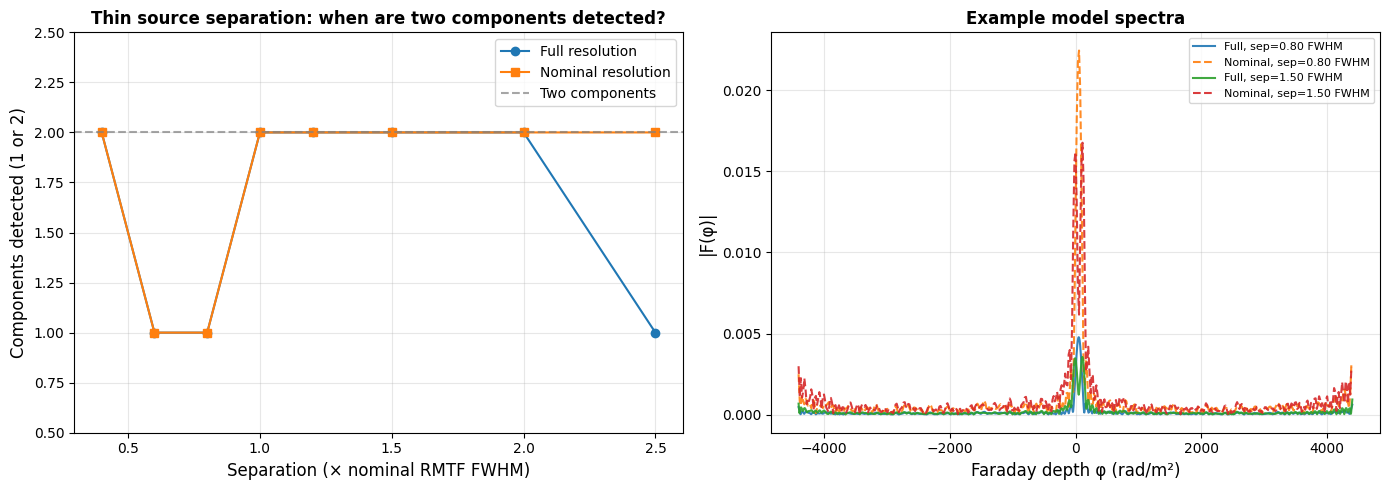

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: components detected (1 or 2) vs separation
ax = axes[0]
ax.plot(separations_fwhm, [r[1] for r in results_full], 'o-', label='Full resolution', color='C0')
ax.plot(
    separations_fwhm, [r[1] for r in results_nominal], 's-', label='Nominal resolution', color='C1'
)
ax.axhline(2, color='gray', linestyle='--', alpha=0.7, label='Two components')
ax.set_xlabel('Separation (× nominal RMTF FWHM)', fontsize=12)
ax.set_ylabel('Components detected (1 or 2)', fontsize=12)
ax.set_title(
    'Thin source separation: when are two components detected?', fontsize=12, fontweight='bold'
)
ax.set_ylim(0.5, 2.5)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: example spectra at 0.8 and 1.5 FWHM (full vs nominal)
ax = axes[1]
idx_show = [2, 5]  # 0.8 and 1.5 FWHM
for i in idx_show:
    phi_f = np.asarray(asnumpy(results_full[i][2].parameter.phi))
    phi_n = np.asarray(asnumpy(results_nominal[i][2].parameter.phi))
    m_f = np.asarray(asnumpy(results_full[i][2].fd_model))
    m_n = np.asarray(asnumpy(results_nominal[i][2].fd_model))
    ax.plot(phi_f, np.abs(m_f), '-', label=f'Full, sep={separations_fwhm[i]:.2f} FWHM', alpha=0.9)
    ax.plot(
        phi_n, np.abs(m_n), '--', label=f'Nominal, sep={separations_fwhm[i]:.2f} FWHM', alpha=0.9
    )
ax.set_xlabel('Faraday depth φ (rad/m²)', fontsize=12)
ax.set_ylabel('|F(φ)|', fontsize=12)
ax.set_title('Example model spectra', fontsize=12, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()